# Synthetic Trend-Oriented Time Series

This notebook generates multiple univariate signals that emphasize trend behaviors—linear, quadratic, exponential, logistic, Gompertz, power-law, step, piecewise-linear, and Gaussian-shaped trajectories—plus visualizations and CSV exports for quick inspection and downstream experiments.


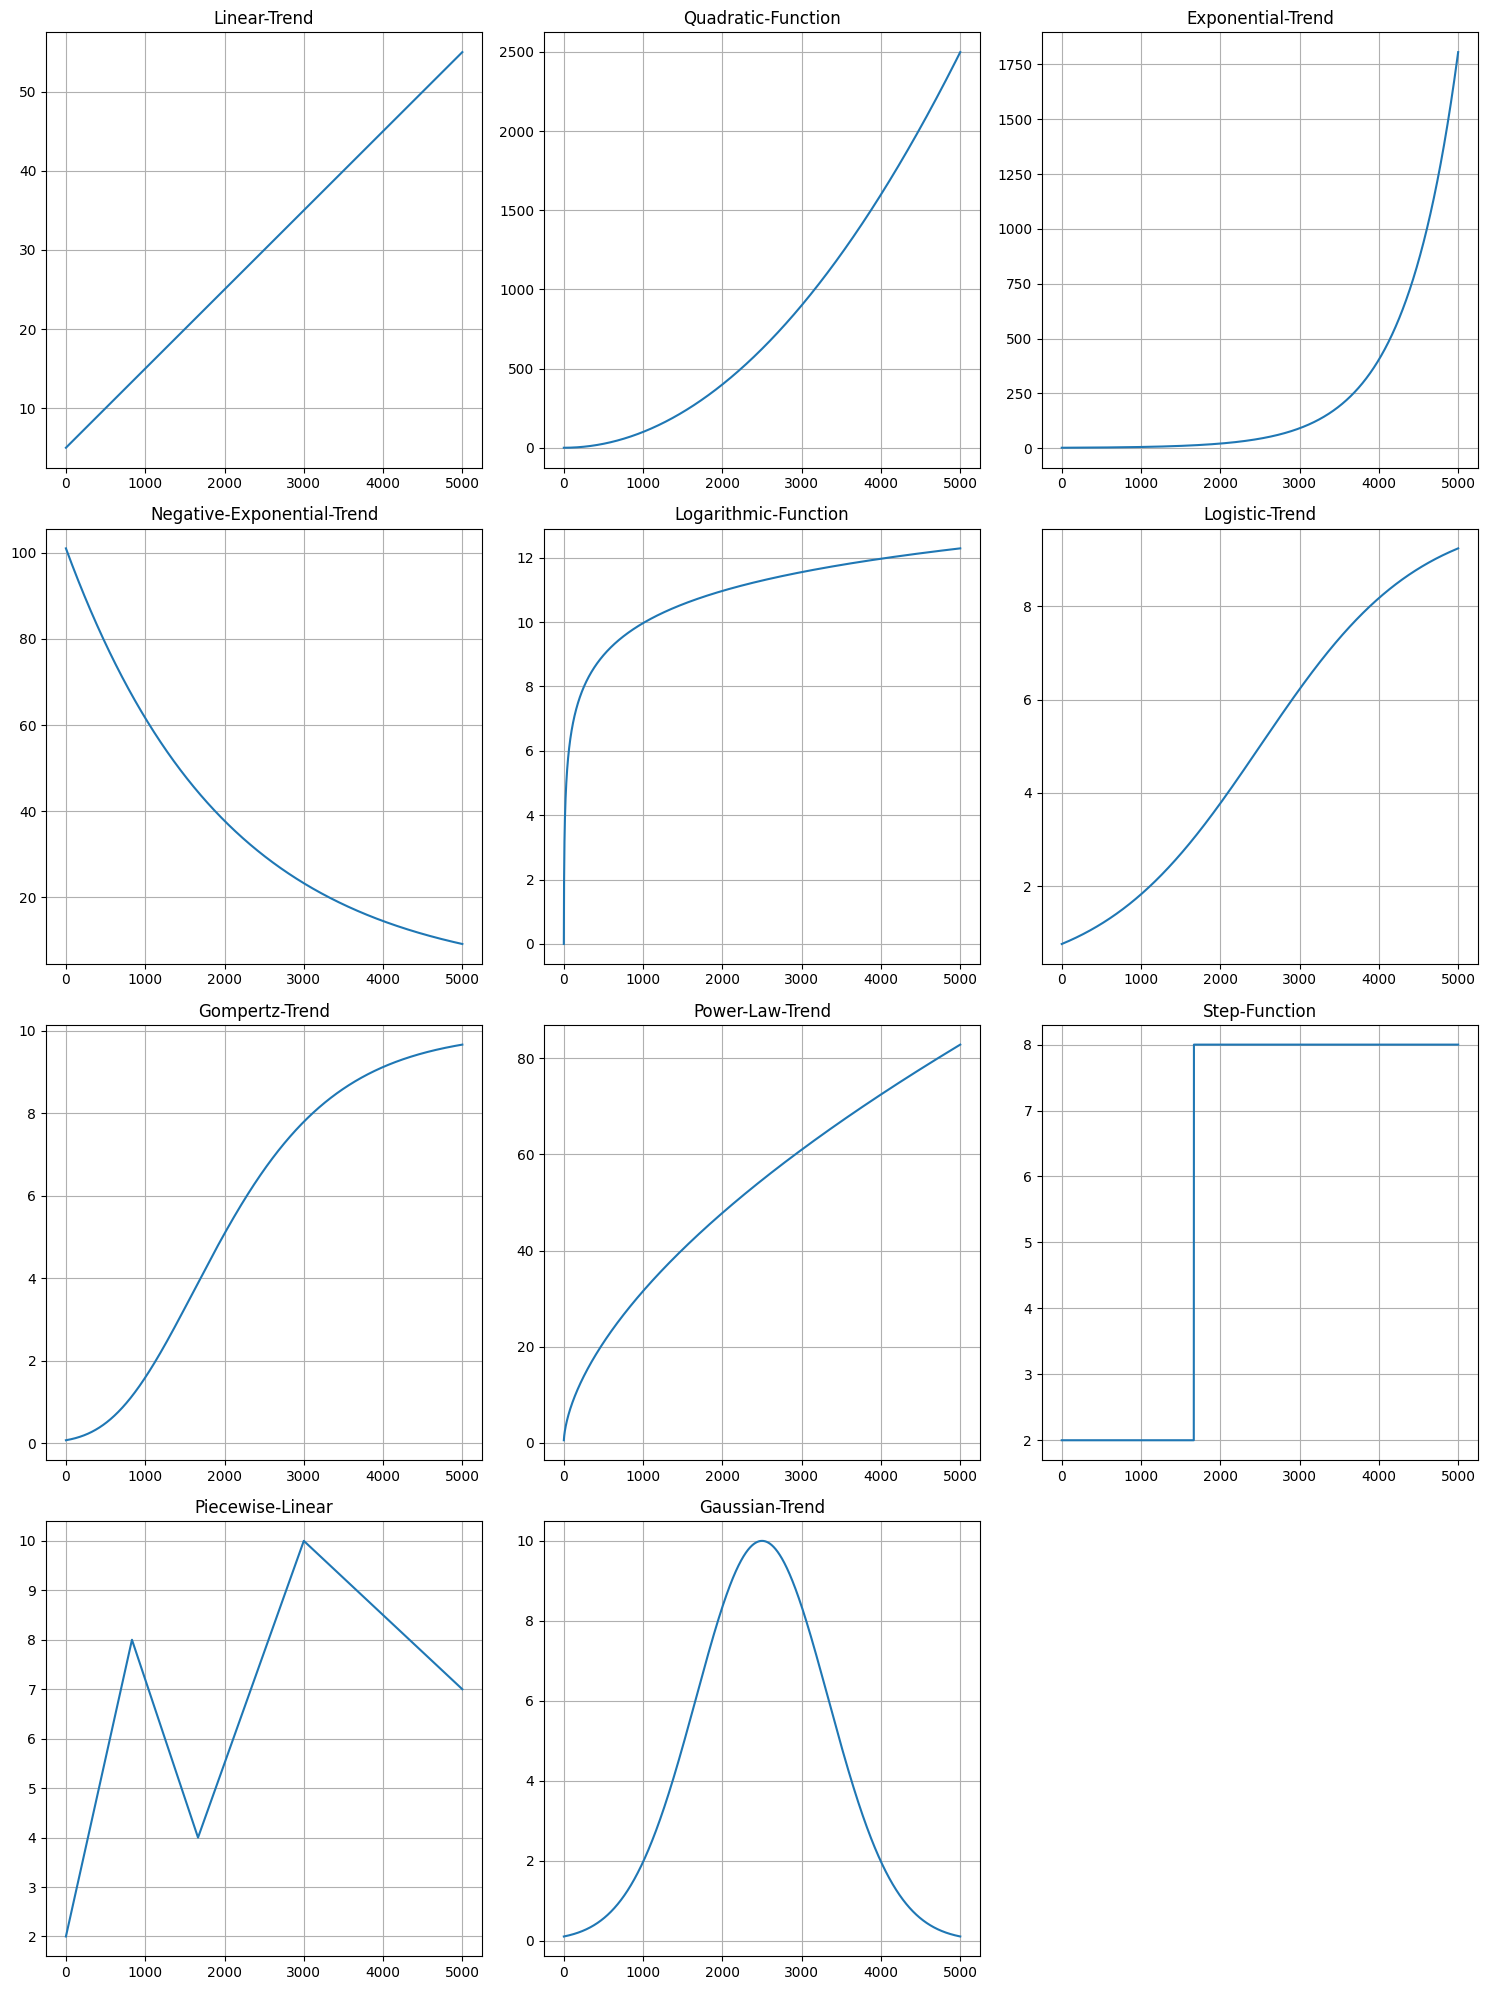

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from statsmodels.tsa.arima_process import ArmaProcess
import pandas as pd

# Shared helper functions for signal generation/noise utilities
try:
    from dataset.signal_generators import *
except ModuleNotFoundError:
    from signal_generators import *

# Main functions
def generate_and_save_datasets(seed, dataset_folder, dataset_id):
    """Generate and save a dataset with different trend signals"""
    n = 5000  # Signal length
    np.random.seed(seed)  # Set random seed
    
    # Dictionary of signal generators
    signal_generators = {
        "Linear-Trend": lambda: generate_linear_signal(n, slope=0.01, intercept=5),
        "Quadratic-Function": lambda: generate_quadratic_signal(n, a=0.0001, b=0, c=0),
        "Exponential-Trend": lambda: generate_exponential_signal(n, rate=0.0015),
        "Negative-Exponential-Trend": lambda: generate_exponential_signal(n, rate=-0.0005, a=100),
        "Logarithmic-Function": lambda: generate_logarithmic_signal(n, base=2),
        "Logistic-Trend": lambda: generate_logistic_signal(n, L=10, k=0.001),
        "Gompertz-Trend": lambda: generate_gompertz_signal(n, a=10, b=5, k=0.001),
        "Power-Law-Trend": lambda: generate_power_law_signal(n, a=0.5, b=0.6),
        "Step-Function": lambda: generate_step_signal(n, t0=n//3, c=2, d=8),
        "Piecewise-Linear": lambda: generate_piecewise_linear_signal(
            n, 
            breakpoints=[0, n//6, n//3, 3*n//5, n-1], 
            values=[2, 8, 4, 10, 7]
        ),
        "Gaussian-Trend": lambda: generate_gaussian_signal(n, a=10, sigma=n/6),
    }
    
    # 1. Generate and save raw dataset
    signal_data_dict = {}
    for signal_name, generator in signal_generators.items():
        signal_data = generator()
        signal_data_dict[signal_name] = signal_data
        save_signal(signal_data, dataset_folder, signal_name, dataset_id=dataset_id, category="raw", length=n)
    
    # Visualize raw signals
    plot_signals(signal_data_dict)

def generate_multiple_datasets(num_datasets=5):
    """Generate multiple datasets with different random seeds"""
    output_folder = "Dataset_generated_trend"  
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    for i in range(num_datasets):
        seed = i
        generate_and_save_datasets(seed, output_folder, i+1)

if __name__ == "__main__":
    generate_multiple_datasets(num_datasets=1)